# Plot SPARC free-parameter scan results

Assumes `scan_free_param.py` has already been run. Reads
`scan_results_SPARC_N5/SPARC_DN_PRD.geqdsk/` (saved `ne_*.npy`, success/failure CSVs)
and compares converged profiles to the TRANSP reference density.

In [1]:
import csv
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.interpolate import interp1d

%matplotlib inline

HERE = Path.cwd()
ROOT = HERE.parent.parent.parent  # saarelma-conner-ped/
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(HERE))

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))

from scan_free_param import (
    TRANSP_PATH,
    load_sparc_inputs,
    read_transp_profiles,
    scan_success_dir,
)
from src.solver_nondim import saarelma_connor_nondim

eq_tag = 'SPARC_DN_PRD.geqdsk'
scan_dir = scan_success_dir / eq_tag
success_fp = scan_dir / 'success_SPARC.txt'
failure_fp = scan_dir / 'failure_SPARC.txt'

# Filename keys: nc before n so ncx_x0_ratio is not parsed as n.
pattern = re.compile(r'_(nc|a|C|D|n|b)([0-9.eE+-]+)')

print(f'scan_dir = {scan_dir}')
print(f'npy files: {len(list(scan_dir.glob("ne_*.npy")))}')

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


scan_dir = /mnt/homes_global/jal2351/software/saarelma-conner-ped/examples/device_prediction/SPARC/scan_results_SPARC_cgyro_N3_psi0.85/SPARC_DN_PRD.geqdsk
npy files: 112


In [2]:
# TRANSP reference ne on psi_N, plus x <-> psi_N map from a base model
# (same construction as scan_free_param.py; no solve needed).
profiles = read_transp_profiles(TRANSP_PATH)
pf = profiles['polflux']
psi_transp = (pf - pf[0]) / (pf[-1] - pf[0])
ne_transp = profiles['ne']  # m^-3

mhd_fp, manual_profs, P_tot_e, Zeff = load_sparc_inputs()
ref = saarelma_connor_nondim(
    P_tot_e=P_tot_e,
    alpha_crit=0.1,
    C_KBM=0.1,
    De_chie_etg=0.1,
    nFC_x0=1e14,
    ncx_x0_ratio=1.259,
    psi_N_inner_boundary=0.85,
    mhd_fp=mhd_fp,
    kprof_loc='manual rho grid',
    manual_profs=manual_profs,
    species='D-T',
    Z_i=Zeff,
    verbose=False,
)

x_shift = ref.r_psi - ref.r_psi[-1]  # m, separatrix = 0
psi_to_x = interp1d(
    ref.psi_N_pres, x_shift,
    kind='linear', bounds_error=False, fill_value='extrapolate',
)
x_to_psi = interp1d(
    x_shift, ref.psi_N_pres,
    kind='linear', bounds_error=False, fill_value='extrapolate',
)

x_transp = psi_to_x(psi_transp)
print(f'TRANSP ne max = {ne_transp.max():.3e} m^-3')
print(f'x_sep domain from map: [{x_shift.min():.4f}, {x_shift.max():.4f}] m')

Using existing gEQDSK: /mnt/homes_global/jal2351/software/saarelma-conner-ped/examples/device_prediction/SPARC/gSPARC_DN_PRD.geqdsk
Loaded 6 - cgyro_20221013.txt (cgyro): 201 profile points
POPCON: P_ohmic=1.70 MW, P_RF=11.10 MW, P_tot_e=6.40 MW, Zeff=1.5
TRANSP ne max = 4.166e+20 m^-3
x_sep domain from map: [-0.4858, 0.0000] m


rank  alpha_crit     C_KBM  De_chie_etg        nFC_x0  ncx_x0_ratio       L2 (m^-3)
-----------------------------------------------------------------------------------
   1          10       0.1            1         1e+15          17.8       1.200e+19
   2          10         1            1         1e+15          17.8       1.200e+19
   3          10        10            1         1e+15          17.8       1.200e+19
   4         0.1       0.1           10         1e+17          1.26       1.201e+19
   5           1       0.1          0.1         1e+15          4.73       4.697e+19
   6           1        10          0.1         1e+15          4.73       4.697e+19
   7          10       0.1          0.1         1e+15          4.73       4.697e+19
   8          10         1          0.1         1e+15          4.73       4.697e+19
   9          10        10          0.1         1e+15          4.73       4.697e+19
  10           1         1          0.1         1e+15          4.73       4.

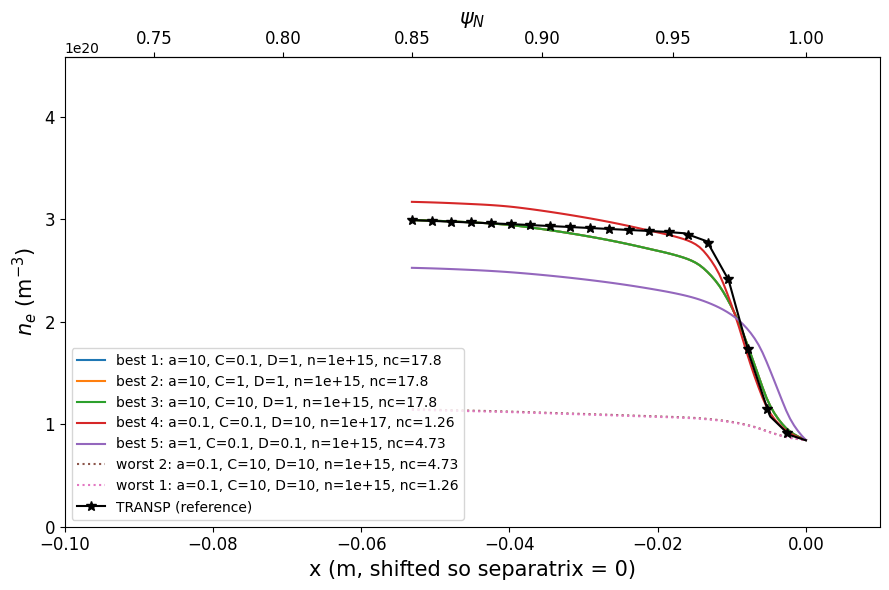

In [3]:
# Rank successful runs by L2 distance to TRANSP ne on a common pedestal grid,
# then plot top 5 (solid) and worst 2 (dotted) vs TRANSP.

psi_ped = np.linspace(0.85, 1.0, 200)
x_ped = psi_to_x(psi_ped)

ne_transp_ped = interp1d(
    psi_transp, ne_transp, kind='linear',
    bounds_error=False, fill_value='extrapolate',
)(psi_ped)
ne_transp_of_x = interp1d(
    x_transp, ne_transp, kind='linear',
    bounds_error=False, fill_value='extrapolate',
)

def _sol_xy(sol):
    """SPARC scan saves a dict {'x', 'y', ...}; y is 1-D ne."""
    if isinstance(sol, dict):
        return np.asarray(sol['x']), np.asarray(sol['y'])
    y = sol.y[0] if np.ndim(sol.y) > 1 else sol.y
    return np.asarray(sol.x), np.asarray(y)


results_l2 = []
for npy_path in scan_dir.glob('ne_*.npy'):
    pairs = pattern.findall(npy_path.stem)
    params = {key: float(num) for key, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    sol_x, sol_ne = _sol_xy(sol)
    ne_pred_ped = interp1d(
        sol_x, sol_ne, kind='linear',
        bounds_error=False, fill_value='extrapolate',
    )(x_ped)
    l2 = np.sqrt(np.mean((ne_pred_ped - ne_transp_ped) ** 2))  # RMS in m^-3
    results_l2.append({
        'alpha_crit':  params.get('a'),
        'C_KBM':       params.get('C'),
        'De_chie_etg': params.get('D'),
        'nFC_x0':      params.get('n'),
        'ncx_x0_ratio': params.get('nc'),
        'l2':          l2,
        'sol_x':       sol_x,
        'sol_ne':      sol_ne,
    })

results_l2.sort(key=lambda r: r['l2'])

header = (f"{'rank':>4}  {'alpha_crit':>10}  {'C_KBM':>8}  {'De_chie_etg':>11}  "
          f"{'nFC_x0':>12}  {'ncx_x0_ratio':>12}  {'L2 (m^-3)':>14}")
print(header)
print('-' * len(header))
for rank, r in enumerate(results_l2, start=1):
    print(f"{rank:>4}  {r['alpha_crit']:>10.3g}  {r['C_KBM']:>8.3g}  "
          f"{r['De_chie_etg']:>11.3g}  {r['nFC_x0']:>12.3g}  "
          f"{r['ncx_x0_ratio']:>12.3g}  {r['l2']:>14.3e}")


def _label(r):
    return (f"a={r['alpha_crit']:.3g}, C={r['C_KBM']:.3g}, "
            f"D={r['De_chie_etg']:.3g}, n={r['nFC_x0']:.3g}, "
            f"nc={r['ncx_x0_ratio']:.3g}")


fig, ax = plt.subplots(figsize=(9, 6))
for i, r in enumerate(results_l2[:5]):
    ax.plot(r['sol_x'], r['sol_ne'], '-', label=f'best {i+1}: {_label(r)}')
for i, r in enumerate(results_l2[-2:]):
    ax.plot(r['sol_x'], r['sol_ne'], ':', label=f'worst {2-i}: {_label(r)}')

plotted = results_l2[:5] + results_l2[-2:]
x_lo = min(r['sol_x'].min() for r in plotted)
x_hi = max(r['sol_x'].max() for r in plotted)
x_exp = np.linspace(x_lo, x_hi, 400)
ax.plot(x_exp, ne_transp_of_x(x_exp), '-*', color='black', markevery=20,
        markersize=7, label='TRANSP (reference)')

ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'$n_e$ (m$^{-3}$)', fontsize=15)
ax.legend(fontsize=10, loc='best')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-0.1, 0.01)
ax.set_ylim(0, 1.1 * float(ne_transp.max()))
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
secax.tick_params(axis='x', labelsize=12)
plt.tight_layout()
plt.show()

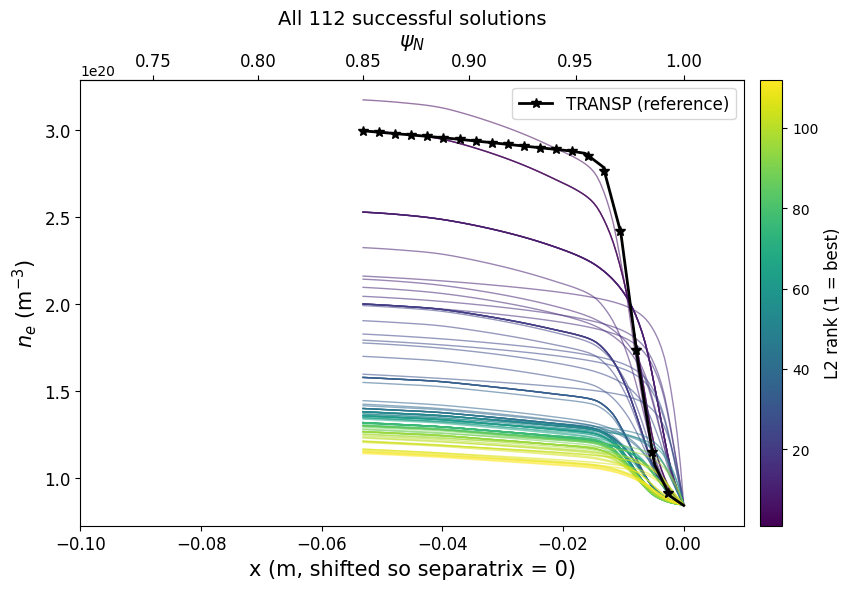

In [4]:
# Plot all successful solutions vs TRANSP (colored by L2 rank).

fig, ax = plt.subplots(figsize=(9, 6))
n = len(results_l2)
cmap = plt.cm.viridis
for rank, r in enumerate(results_l2):
    color = cmap(rank / max(n - 1, 1))
    ax.plot(r['sol_x'], r['sol_ne'], '-', color=color, alpha=0.55, linewidth=1.0)

x_lo = min(r['sol_x'].min() for r in results_l2)
x_hi = max(r['sol_x'].max() for r in results_l2)
x_exp = np.linspace(x_lo, x_hi, 400)
ax.plot(x_exp, ne_transp_of_x(x_exp), '-*', color='black', markevery=20,
        markersize=7, linewidth=2, zorder=10, label='TRANSP (reference)')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=n))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('L2 rank (1 = best)', fontsize=12)

ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'$n_e$ (m$^{-3}$)', fontsize=15)
ax.legend(fontsize=12, loc='best')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-0.1, 0.01)
# ax.set_ylim(0, 10 * float(ne_transp.max()))
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
secax.tick_params(axis='x', labelsize=12)
ax.set_title(f'All {n} successful solutions', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# 5x5 panel plot over the five scanned free parameters. 
# Off-diagonal: all combinations projected onto a 2D (param_x, param_y) slice.
# Successes: colored by normalized L2 to TRANSP ne. Failures: grey x markers.

psi_ped_grid = np.linspace(0.85, 1.0, 200)
x_ped_grid = psi_to_x(psi_ped_grid)
ne_transp_on_ped = interp1d(
    psi_transp, ne_transp, kind='linear',
    bounds_error=False, fill_value='extrapolate',
)(psi_ped_grid)
mean_ne_transp = float(np.mean(ne_transp_on_ped))

success_records = []  # a, C, D, n, nc, L2/mean_ne
for npy_path in scan_dir.glob('ne_*.npy'):
    pairs = pattern.findall(npy_path.stem)
    params = {key: float(num) for key, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    sol_x, sol_ne = _sol_xy(sol)
    ne_pred_on_ped = interp1d(
        sol_x, sol_ne, kind='linear',
        bounds_error=False, fill_value='extrapolate',
    )(x_ped_grid)
    l2 = np.sqrt(np.mean((ne_pred_on_ped - ne_transp_on_ped) ** 2))
    success_records.append((
        params.get('a'), params.get('C'), params.get('D'),
        params.get('n'), params.get('nc'), l2 / mean_ne_transp,
    ))
success_arr = np.array(success_records)

# failure_SPARC.txt: eq_tag, alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, psi_N_inner
failure_records = []
with open(failure_fp, newline='') as f:
    reader = csv.reader(f)
    next(reader)  # header
    for row in reader:
        # five free params only (skip eq_tag and fixed psi_N_inner)
        failure_records.append([float(x.strip()) for x in row[1:6]])
failure_arr = np.array(failure_records) if failure_records else np.empty((0, 5))

panel_names = ['alpha_crit', 'C_KBM', 'De_chie_etg', 'nFC_x0', 'ncx_x0_ratio']
panel_labels = [r'$\alpha_{\mathrm{crit}}$',
                r'$C_{\mathrm{KBM}}$',
                r'$D_{e}\chi_{e}^{\mathrm{ETG}}$',
                r'$n_{\mathrm{FC}}^{x_0}$ (m$^{-3}$)',
                r'$n_{\mathrm{CX}}^{x_0}/n_{\mathrm{FC}}^{x_0}$']
log_axis = [True, True, True, True, True]

norm = Normalize(vmin=float(success_arr[:, 5].min()),
                 vmax=float(success_arr[:, 5].max()))
cmap = plt.get_cmap('viridis')

fig, axes = plt.subplots(5, 5, figsize=(15, 15),
                         gridspec_kw=dict(wspace=0.08, hspace=0.08))

for row in range(5):
    for col in range(5):
        ax = axes[row, col]
        if row == col:
            ax.set_visible(False)
            continue

        if failure_arr.size:
            ax.scatter(failure_arr[:, col], failure_arr[:, row],
                       marker='x', color='gray', alpha=0.35, s=28,
                       linewidths=1.0)
        sc = ax.scatter(success_arr[:, col], success_arr[:, row],
                        c=success_arr[:, 5], cmap=cmap, norm=norm,
                        marker='o', s=32, edgecolors='black', linewidths=0.3)

        if log_axis[col]:
            ax.set_xscale('log')
        if log_axis[row]:
            ax.set_yscale('log')

        top_visible_row = 0 if col != 0 else 1
        bottom_visible_row = 4 if col != 4 else 3
        show_top_x = row == top_visible_row
        show_bottom_x = row == bottom_visible_row

        if show_bottom_x:
            ax.set_xlabel(panel_labels[col], fontsize=12)
            ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
        else:
            ax.tick_params(axis='x', which='both', bottom=True, labelbottom=False)

        if show_top_x:
            ax.xaxis.set_label_position('top')
            ax.tick_params(axis='x', which='both', top=True, labeltop=True)
            if not show_bottom_x:
                ax.set_xlabel(panel_labels[col], fontsize=12)
        else:
            ax.tick_params(axis='x', which='both', top=True, labeltop=False)

        left_visible_col = 0 if row != 0 else 1
        right_visible_col = 4 if row != 4 else 3
        show_left_y = col == left_visible_col
        show_right_y = col == right_visible_col

        if show_left_y:
            ax.set_ylabel(panel_labels[row], fontsize=12)
            ax.tick_params(axis='y', which='both', left=True, labelleft=True)
        else:
            ax.tick_params(axis='y', which='both', left=True, labelleft=False)

        if show_right_y:
            ax.yaxis.set_label_position('right')
            ax.tick_params(axis='y', which='both', right=True, labelright=True)
            if not show_left_y:
                ax.set_ylabel(panel_labels[row], fontsize=12)
        else:
            ax.tick_params(axis='y', which='both', right=True, labelright=False)

        ax.tick_params(axis='y', which='both', labelsize=8)
        ax.tick_params(axis='x', which='both', labelsize=8)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), orientation='vertical',
                    shrink=0.6, pad=0.02)
cbar.set_label(
    r'$\|n_e^{\mathrm{model}} - n_e^{\mathrm{TRANSP}}\|_2 \;/\; '
    r'\langle n_e^{\mathrm{TRANSP}}\rangle$',
    fontsize=12,
)
plt.show()

print(f'successes plotted: {len(success_arr)}, failures: {len(failure_arr)}')

In [ ]:
# Ionization (S_i) and charge-exchange (S_cx) rate coefficients vs radius.
# base_model == ref from the setup cell; rates live on psi_Te_eval.

base_model = ref
x_rates = psi_to_x(np.asarray(base_model.psi_Te_eval, dtype=float))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x_rates, base_model.S_i, '-', label=r'$S_i$ (ionization)')
ax.plot(x_rates, base_model.S_cx, '-', label=r'$S_{cx}$ (charge exchange)')

ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'rate coefficient (m$^3$/s)', fontsize=15)
ax.legend(fontsize=12, loc='best')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(float(np.min(x_rates)), 0.01)
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
secax.tick_params(axis='x', labelsize=12)
ax.set_title(r'$S_i$ and $S_{cx}$ from base model', fontsize=14)
plt.tight_layout()
plt.show()


# Compare with a high performing PT H-mode Snyder DIII-D case

In [ ]:
# compare to a DIII-D Snyder case
from pathlib import Path
import sys
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Equilibria parameters
geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode')
pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode')
equil_num = len(list(pfile_dir.glob('*.cdf')))
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.load_equil import initialize_inputs
from src.solver_nondim import saarelma_connor_nondim

equilibria = initialize_inputs(equil_num, geqdsk_dir, pfile_dir, p_filetype='OMFITnc')


In [ ]:

i=0
for mhd_fp, kprof_fp in equilibria:
    ref = saarelma_connor_nondim(
        P_tot_e=3e5,
        alpha_crit=0.1,
        C_KBM=0.1,
        De_chie_etg=0.1,
        nFC_x0=1e14,
        ncx_x0_ratio=1.259,
        psi_N_inner_boundary=0.85,
        mhd_fp=mhd_fp,
        kprof_fp=kprof_fp,
        kprof_loc='OMFITnc',
        # manual_profs=manual_profs,
        species='D-T',
        Z_i=1,
        verbose=False,
    )

    # Ionization (S_i) and charge-exchange (S_cx) rate coefficients vs radius.
    # base_model == ref from the setup cell; rates live on psi_Te_eval.

    x_shift = ref.r_psi - ref.r_psi[-1]  # m, separatrix = 0
    psi_to_x = interp1d(
        ref.psi_N_pres, x_shift,
        kind='linear', bounds_error=False, fill_value='extrapolate',
    )
    x_to_psi = interp1d(
        x_shift, ref.psi_N_pres,
        kind='linear', bounds_error=False, fill_value='extrapolate',
    )

    base_model = ref
    x_rates = psi_to_x(np.asarray(base_model.psi_Te_eval, dtype=float))

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(x_rates, base_model.S_i, '-', label=r'$S_i$ (ionization)')
    ax.plot(x_rates, base_model.S_cx, '-', label=r'$S_{cx}$ (charge exchange)')

    ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
    ax.set_ylabel(r'rate coefficient (m$^3$/s)', fontsize=15)
    ax.legend(fontsize=12, loc='best')
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlim(float(np.min(x_rates)), 0.01)
    secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
    secax.set_xlabel(r'$\psi_N$', fontsize=15)
    secax.tick_params(axis='x', labelsize=12)
    ax.set_title(r'$S_i$ and $S_{cx}$ from base model', fontsize=14)
    plt.tight_layout()
    plt.show()

    if i>0:
        break
    i+=1

In [ ]:
scan_dir_Snyder = Path('/mnt/homes_global/jal2351/software/saarelma-conner-ped/examples/device_prediction/SPARC/scan_results_Snyder_N3_psi0.85/125730.02445')

N = 3
alpha_crits = np.logspace(-1, 1, N)
C_KBMs = np.logspace(-1, 1, N)
De_chie_etgs = np.logspace(-1, 1, N)
nFC_x0s = np.logspace(15, 17, 3)
ncx_x0_ratios = np.logspace(0.1, 1.25, N)
psi_val = 0.85
x_res = 20
verbose = False
scan_success_dir = HERE / (f'scan_results_Snyder_N{N}_psi{psi_val}')
success_fp = Path('success_SPARC.txt')
failure_fp = Path('failure_SPARC.txt')
error_messages_fp = Path('error_messages_SPARC.txt')
SOLVE_KW = dict(
    x_res=x_res,
    fe_degree=2,
    initial_guess='tanh',
    ne_inner_bc='neumann',
    linear_solver='lu',
    nCX_ic='scale nFC',
    kbm_treatment='picard',
    kbm_gate_eps=0.1,
    picard_gate_mode='average',
    picard_max_it=50,
    picard_rtol=1e-8,
    picard_relax=1.0,
    bc_origin='p-file',
    verbose=verbose,
)
eq_tag = Path(mhd_fp).name[1:]  # e.g. SPARC_DN_PRD.geqdsk
eq_dir = scan_success_dir / eq_tag
eq_dir.mkdir(parents=True, exist_ok=True)

eq_success_fp = eq_dir / success_fp
eq_failure_fp = eq_dir / failure_fp
eq_error_fp = eq_dir / error_messages_fp

for old in eq_dir.glob('ne_*.npy'):
    old.unlink()
for fp in (eq_success_fp, eq_failure_fp, eq_error_fp):
    fp.unlink(missing_ok=True)
with open(eq_success_fp, 'w') as f:
    f.write('eq_tag, alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, '
            'psi_N_inner, L2_error\n')
with open(eq_failure_fp, 'w') as f:
    f.write('eq_tag, alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, '
            'psi_N_inner\n')
with open(eq_error_fp, 'w') as f:
    f.write('eq_tag, alpha_crit, C_KBM, De_chie_etg, nFC_x0, ncx_x0_ratio, '
            'psi_N_inner, message\n')


In [ ]:
n_ok = n_fail = 0
n_total = (len(alpha_crits) * len(C_KBMs) * len(De_chie_etgs)
            * len(nFC_x0s) * len(ncx_x0_ratios))
i_combo = 0

for alpha_crit in alpha_crits:
    for C_KBM in C_KBMs:
        for De_chie_etg in De_chie_etgs:
            for nFC_x0 in nFC_x0s:
                for ncx_x0_ratio in ncx_x0_ratios:
                    i_combo += 1
                    ac = round(float(alpha_crit), 3)
                    ck = round(float(C_KBM), 3)
                    de = round(float(De_chie_etg), 3)
                    nf = round(float(nFC_x0), 3)
                    nc = round(float(ncx_x0_ratio), 3)
                    try:
                        base_model.update_free_params(
                            alpha_crit=ac,
                            C_KBM=ck,
                            De_chie_etg=de,
                            nFC_x0=nf,
                            ncx_x0_ratio=nc,
                            psi_N_inner_boundary=psi_val,
                        )
                        x_sol, ne_sol, nFC_sol, nCX_sol, T_e_pres, psi_N_pres = (
                            base_model.solve_coupled_nondim(**SOLVE_KW)
                        )
                        sol = {
                            'x': x_sol, 'y': ne_sol,
                            'nFC': nFC_sol, 'nCX': nCX_sol,
                            'T_e_pres': T_e_pres, 'psi_N_pres': psi_N_pres,
                        }
                    except Exception as e:
                        n_fail += 1
                        with open(eq_failure_fp, 'a') as f:
                            f.write(
                                f'{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, '
                                f'{psi_val:.4f}\n'
                            )
                        with open(eq_error_fp, 'a') as f:
                            f.write(
                                f'{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, '
                                f'{psi_val:.4f}, {e}\n'
                            )
                    else:
                        n_ok += 1
                        # L2 vs input kinetic profiles on the solution grid
                        ne_ref = interp1d(
                            base_model.x_init, base_model.n_e_pres,
                            kind='linear', bounds_error=False,
                            fill_value='extrapolate',
                        )(x_sol)
                        L2_error = (
                            np.linalg.norm(ne_sol - ne_ref)
                            / np.linalg.norm(ne_ref)
                        )
                        with open(eq_success_fp, 'a') as f:
                            f.write(
                                f'{eq_tag}, {ac}, {ck}, {de}, {nf}, {nc}, '
                                f'{psi_val:.4f}, {L2_error}\n'
                            )
                        np.save(
                            eq_dir / (
                                f'ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}'
                                f'_b{psi_val:.4f}'
                            ),
                            sol,
                            allow_pickle=True,
                        )

                    if i_combo % 20 == 0 or i_combo == n_total:
                        print(f'  {i_combo}/{n_total}  '
                                f'(ok={n_ok}, fail={n_fail})')

print(f'Done. Saved under {eq_dir}  (ok={n_ok}, fail={n_fail})')

In [ ]:
results_l2 = []
for npy_path in scan_dir_Snyder.glob('ne_*.npy'):
    pairs = pattern.findall(npy_path.stem)
    params = {key: float(num) for key, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    sol_x, sol_ne = _sol_xy(sol)
    ne_pred_ped = interp1d(
        sol_x, sol_ne, kind='linear',
        bounds_error=False, fill_value='extrapolate',
    )(x_ped)
    l2 = np.sqrt(np.mean((ne_pred_ped - ne_transp_ped) ** 2))  # RMS in m^-3
    results_l2.append({
        'alpha_crit':  params.get('a'),
        'C_KBM':       params.get('C'),
        'De_chie_etg': params.get('D'),
        'nFC_x0':      params.get('n'),
        'ncx_x0_ratio': params.get('nc'),
        'l2':          l2,
        'sol_x':       sol_x,
        'sol_ne':      sol_ne,
    })

results_l2.sort(key=lambda r: r['l2'])

header = (f"{'rank':>4}  {'alpha_crit':>10}  {'C_KBM':>8}  {'De_chie_etg':>11}  "
          f"{'nFC_x0':>12}  {'ncx_x0_ratio':>12}  {'L2 (m^-3)':>14}")
print(header)
print('-' * len(header))
for rank, r in enumerate(results_l2, start=1):
    print(f"{rank:>4}  {r['alpha_crit']:>10.3g}  {r['C_KBM']:>8.3g}  "
          f"{r['De_chie_etg']:>11.3g}  {r['nFC_x0']:>12.3g}  "
          f"{r['ncx_x0_ratio']:>12.3g}  {r['l2']:>14.3e}")


def _label(r):
    return (f"a={r['alpha_crit']:.3g}, C={r['C_KBM']:.3g}, "
            f"D={r['De_chie_etg']:.3g}, n={r['nFC_x0']:.3g}, "
            f"nc={r['ncx_x0_ratio']:.3g}")


fig, ax = plt.subplots(figsize=(9, 6))
for i, r in enumerate(results_l2[:5]):
    ax.plot(r['sol_x'], r['sol_ne'], '-', label=f'best {i+1}: {_label(r)}')
for i, r in enumerate(results_l2[-2:]):
    ax.plot(r['sol_x'], r['sol_ne'], ':', label=f'worst {2-i}: {_label(r)}')

plotted = results_l2[:5] + results_l2[-2:]
x_lo = min(r['sol_x'].min() for r in plotted)
x_hi = max(r['sol_x'].max() for r in plotted)
x_exp = np.linspace(x_lo, x_hi, 400)
# ax.plot(x_exp, ne_transp_of_x(x_exp), '-*', color='black', markevery=20,
#         markersize=7, label='TRANSP (reference)')

ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'$n_e$ (m$^{-3}$)', fontsize=15)
ax.legend(fontsize=10, loc='best')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-0.1, 0.01)
ax.set_ylim(0, 1e20)
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
secax.tick_params(axis='x', labelsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Plot all successful solutions vs TRANSP (colored by L2 rank).

fig, ax = plt.subplots(figsize=(9, 6))
n = len(results_l2)
cmap = plt.cm.viridis
for rank, r in enumerate(results_l2):
    color = cmap(rank / max(n - 1, 1))
    ax.plot(r['sol_x'], r['sol_ne'], '-', color=color, alpha=0.55, linewidth=1.0)

x_lo = min(r['sol_x'].min() for r in results_l2)
x_hi = max(r['sol_x'].max() for r in results_l2)
x_exp = np.linspace(x_lo, x_hi, 400)
# ax.plot(x_exp, ne_transp_of_x(x_exp), '-*', color='black', markevery=20,
#         markersize=7, linewidth=2, zorder=10, label='TRANSP (reference)')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=1, vmax=n))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('L2 rank (1 = best)', fontsize=12)

ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'$n_e$ (m$^{-3}$)', fontsize=15)
ax.legend(fontsize=12, loc='best')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-0.1, 0.01)
ax.set_ylim(0, 1e20)
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
secax.tick_params(axis='x', labelsize=12)
ax.set_title(f'All {n} successful solutions', fontsize=14)
plt.tight_layout()
plt.show()
